# Feature Engineering

The objective of this notebook is to transform historical market data into informative features that capture different aspects of asset behavior.

These engineered variables will later be used for dimensionality reduction and clustering in order to identify distinct market regimes.

The selected features focus on three fundamental market characteristics:

- Returns (market direction)
- Volatility (market uncertainty)
- Momentum (trend strength)

Together, these variables provide a compact representation of market dynamics.

-------

## Project Configuration

This section loads the project configuration and paths required to access the processed dataset generated during the exploratory analysis stage.

Using centralized configuration parameters ensures consistency, reproducibility, and support for multiple assets across the entire project pipeline.

In [ ]:
# Load libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
%matplotlib inline

# Ruta absoluta a la raíz del proyecto
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2018-01-01,13657.200195,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


-----

## Load Dataset

The processed dataset generated during the exploratory analysis stage is loaded into memory.

This dataset serves as the starting point for feature creation and contains the historical market information required to compute returns, volatility, and momentum.

In [ ]:
# Load Processed data
if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)

file_path = f"{RAW_DATA_PATH}/{asset_name}_{INTERVAL}_raw.csv"

df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()

------

## Engineered Features Overview

Feature engineering transforms raw market data into variables that are more informative for machine learning algorithms.

For this project, three complementary features are constructed:

- Returns → captures daily market direction.
- Volatility → captures market uncertainty and risk.
- Momentum → captures trend strength.

Together, these features provide a compact representation of market behavior that will later be used for dimensionality reduction and clustering.

-----

## Feature 1: Daily Returns

The first engineered feature is the daily return. Unlike raw prices, returns measure the relative change in value from one trading day to the next.

Returns are widely used in quantitative finance because they provide a standardized measure of market movement that is independent of the asset's absolute price level.

In the context of market regime detection, returns capture the direction and magnitude of daily price movements and serve as a fundamental building block for subsequent features such as volatility and momentum.

This help us estimate how much did the real changed of the asset, relative to its previous value, with the following formula:
$$
r_t = \frac{P_t-P_{t-1}}{P_{t-1}}
$$
Where: 
- $P_t$ = today's price
- $P_{t-1}$ = yesterday's price 


In [17]:
# Create Returns Column
df["Returns"] = df["Close"].pct_change() # pct_changes() calculates the daily percentage yields using the formula above

In [18]:
# Verify the new column
df[["Close", "Returns"]].head(10)

,Close,Returns
Date,,
2018-01-01,13657.200195,NaN
2018-01-02,14982.099609,0.097011
2018-01-03,15201.000000,0.014611
2018-01-04,15599.200195,0.026196
2018-01-05,17429.500000,0.117333
2018-01-06,17527.000000,0.005594
2018-01-07,16477.599609,-0.059873
2018-01-08,15170.099609,-0.079350
2018-01-09,14595.400391,-0.037884


In [19]:
# Analysis interpretation section
df["Returns"].describe()

count    3080.000000
mean        0.001067
std         0.033558
min        -0.371695
25%        -0.013557
50%         0.000629
75%         0.015119
max         0.187465
Name: Returns, dtype: float64

### Interpretation

The descriptive statistics confirm several characteristics previously identified during the exploratory analysis. Daily returns are centered close to zero, with a mean return of approximately 0.11% and a median that is effectively zero, indicating that positive and negative daily movements occur with similar frequency.

The standard deviation of 3.36% reveals substantial day-to-day variability, highlighting the inherently volatile nature of the selected asset.. While the middle 50% of observations lie within a relatively narrow range between approximately -1.36% and +1.51%, extreme observations are also present.

The most severe daily loss reached -37.17%, while the largest daily gain exceeded 18.75%. These values are considerably larger than the typical daily fluctuations and provide further evidence of heavy-tailed behavior and elevated tail risk.

Overall, the return statistics suggest that Bitcoin experiences frequent small daily movements combined with occasional extreme events. This behavior supports the existence of varying market conditions and reinforces the importance of volatility-related features for subsequent market regime detection.

------

## Feature 2: Rolling Volatility

While returns describe individual daily price movements, volatility measures how variable those movements have been over a recent period of time.

Volatility is one of the most widely used risk indicators in quantitative finance because it captures the degree of uncertainty and instability present in the market.

For this project, volatility is computed as the rolling standard deviation of daily returns over a 30-day window. This approach allows the feature to adapt through time and reflect changing market conditions.

In the context of market regime detection, volatility is expected to play a key role in distinguishing stable periods from highly turbulent market environments.

In [20]:
# Create the volatility column
df["Volatility"] = df["Returns"].rolling(window=VOLATILITY_WINDOW).std()

In [21]:
# Verification
df[["Returns", "Volatility"]].head(35)

,Returns,Volatility
Date,,
2018-01-01,NaN,NaN
2018-01-02,0.097011,NaN
2018-01-03,0.014611,NaN
2018-01-04,0.026196,NaN
2018-01-05,0.117333,NaN
2018-01-06,0.005594,NaN
2018-01-07,-0.059873,NaN
2018-01-08,-0.079350,NaN
2018-01-09,-0.037884,NaN


In [29]:
df["Volatility"].describe()

count    3051.000000
mean        0.030725
std         0.012804
min         0.008887
25%         0.022010
50%         0.028126
75%         0.036631
max         0.091330
Name: Volatility, dtype: float64

### Volatility Through Time

To better understand how market uncertainty evolves through time, we visualize the 30-day rolling volatility series.

Periods with higher volatility indicate larger fluctuations in daily returns and greater market uncertainty, while periods with lower volatility suggest more stable market conditions.

By examining volatility through time, we can identify whether the selected asset alternates between calm and turbulent environments, which is a key characteristic of market regimes.

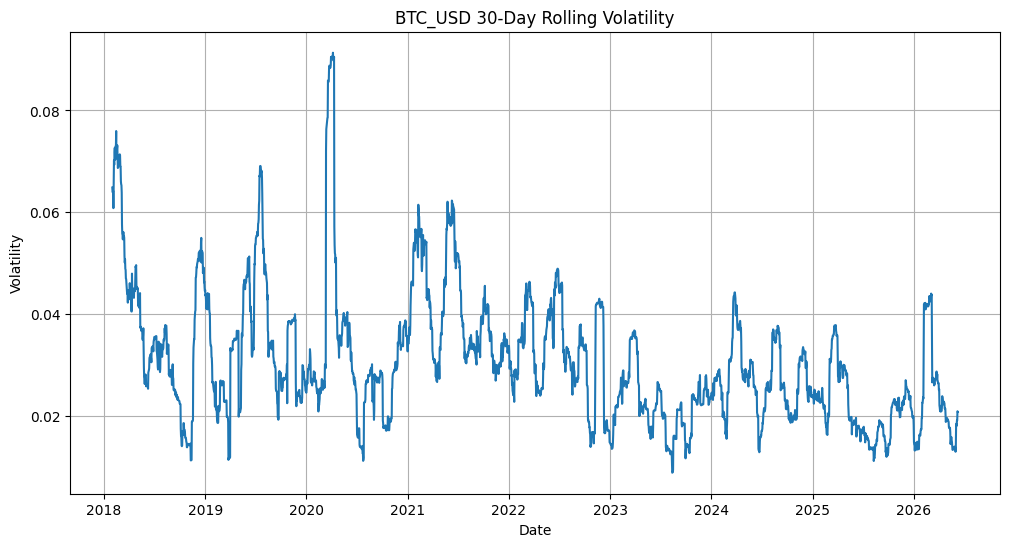

In [22]:
# Chart of volatility through time
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Volatility"])

plt.title(f"{asset_name.upper()} 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)

### Interpretation

The descriptive statistics indicate that the asset's average 30-day rolling volatility is approximately 3.07%, suggesting that daily returns typically fluctuate by around three percent during a given month.

The volatility distribution exhibits substantial variation through time, with values ranging from a minimum of 0.89% to a maximum of 9.13%. This wide range confirms the existence of both calm and highly turbulent market conditions.

The median volatility of 2.81% is relatively close to the mean, indicating that most observations are concentrated around moderate volatility levels. Furthermore, 50% of all observations lie between approximately 2.20% and 3.66%, suggesting that extreme volatility episodes are relatively infrequent but still significant.

The maximum volatility value is nearly three times larger than the average volatility, reinforcing the presence of exceptional periods of market uncertainty. These findings support the hypothesis that Bitcoin experiences distinct volatility regimes and highlight the importance of volatility as a feature for market regime detection.

------

## Feature 3: Momentum

While returns describe daily price movements and volatility captures market uncertainty, momentum measures the strength and direction of recent price trends.

Momentum is calculated as the percentage change between the current closing price and the closing price observed 14 days earlier. Positive momentum values indicate upward price trends, while negative values indicate downward trends.

In the context of market regime detection, momentum provides information about whether the market has been appreciating or depreciating over a recent period, complementing the information captured by returns and volatility.

Using th following formula:
- $P_t$ = today's close
- $P_{t-14}$ = close 14 days ago
$$
Momentum =  \frac{P_t}{P_{t-14}} - 1
$$

In [24]:
# Create the Momentum column
df["Momentum"] = (df["Close"] / df["Close"].shift(MOMENTUM_WINDOW)) - 1

In [25]:
# Validation
df[["Close", "Momentum"]].head(20)

,Close,Momentum
Date,,
2018-01-01,13657.200195,NaN
2018-01-02,14982.099609,NaN
2018-01-03,15201.000000,NaN
2018-01-04,15599.200195,NaN
2018-01-05,17429.500000,NaN
2018-01-06,17527.000000,NaN
2018-01-07,16477.599609,NaN
2018-01-08,15170.099609,NaN
2018-01-09,14595.400391,NaN


In [28]:
df["Momentum"].describe()

count    3067.000000
mean        0.015370
std         0.131446
min        -0.434649
25%        -0.056166
50%         0.006555
75%         0.076607
max         0.658709
Name: Momentum, dtype: float64

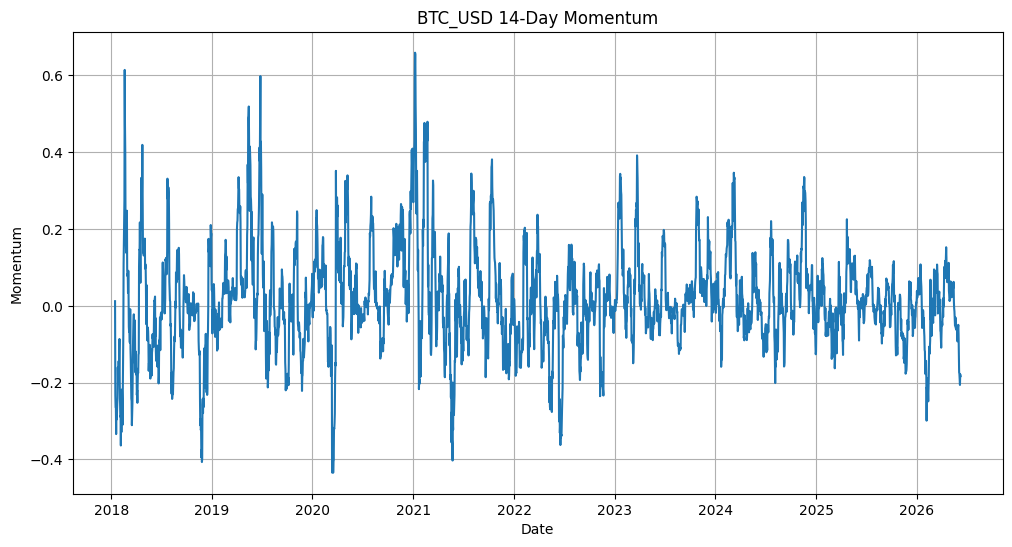

In [30]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Momentum"])

plt.title(f"{asset_name.upper()} 14-Day Momentum")
plt.xlabel("Date")
plt.ylabel("Momentum")

plt.grid(True)

plt.show()

### Interpretation

The momentum statistics reveal that the selected asset generally exhibits positive medium-term price trends, with an average 14-day momentum of approximately 1.54%.

Although the median momentum is close to zero, the distribution spans a wide range of values, indicating that market trends can vary substantially through time. The strongest positive momentum reached approximately 65.87%, while the most negative momentum reached approximately -43.46%, reflecting periods of exceptionally strong upward and downward trends.

The middle 50% of observations lie between approximately -5.62% and 7.66%, suggesting that most momentum values remain within a moderate range. However, the presence of extreme positive and negative observations indicates that Bitcoin occasionally experiences powerful trend movements over relatively short periods.

These results demonstrate that momentum effectively captures trend strength and direction, providing information that complements both returns and volatility. Consequently, momentum is expected to contribute significantly to the identification of different market regimes.

-----

## Final Dataset Preparation

The rolling and lagged calculations used to create volatility and momentum require historical observations. As a result, missing values are introduced at the beginning of the dataset.

This section verifies the generated missing values, removes incomplete observations, and prepares the final feature dataset that will be used in the PCA and clustering stages.

In [ ]:
# Verify how many nulls there are
df[["Returns", "Volatility", "Momentum"]].isnull().sum()

Returns        1
Volatility    30
Momentum      14
dtype: int64

In [36]:
# Create the final dataset
df_features = df[["Returns", "Volatility", "Momentum"]].copy()

df_features.dropna(inplace=True)

df_features.head()

,Returns,Volatility,Momentum
Date,,,
2018-01-31,0.011359,0.064866,-0.086472
2018-02-01,-0.102783,0.064014,-0.200817
2018-02-02,-0.037052,0.063907,-0.239214
2018-02-03,0.038973,0.064239,-0.288723
2018-02-04,-0.097865,0.060821,-0.286471


In [ ]:
# Verify the shape of the new df
df_features.shape

(3051, 3)

In [ ]:
# Create pcrocessed path
Path(PROCESSED_DATA_PATH).mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Output directory ready: "
    f"{PROCESSED_DATA_PATH}"
)

In [39]:
# Saved the data
feature_path = (f"{PROCESSED_DATA_PATH}/{asset_name}_features.csv")

df_features.to_csv(feature_path)

print(f"Features saved to: {feature_path}")

Features saved to: ../data/processed/btc_usd_features.csv


### Interpretation

After removing observations affected by rolling-window calculations, the final dataset contains complete values for all engineered features.

The resulting dataset is now suitable for dimensionality reduction and clustering because every observation contains a valid representation of returns, volatility, and momentum.

This preprocessing step ensures that subsequent machine learning algorithms receive consistent and complete inputs.

----- 

# Conclusion

In this notebook, historical market data was transformed into a set of engineered features designed to capture different dimensions of market behavior.

Three features were constructed and analyzed:

- Returns, which measure daily price movements.
- Volatility, which captures recent market uncertainty through the rolling standard deviation of returns.
- Momentum, which measures the strength and direction of short-term trends.

The analysis revealed that the selected asset exhibits substantial variability across all three dimensions. Returns display heavy-tailed behavior with occasional extreme price movements. Volatility fluctuates significantly through time and exhibits persistence, suggesting the existence of distinct market risk environments. Momentum alternates between positive and negative phases, reflecting changing market trends.

Together, these features provide a compact representation of market dynamics and form the foundation for the next stages of the project. Before applying clustering algorithms, the engineered features will be standardized and analyzed using Principal Component Analysis (PCA) to reduce dimensionality and identify the most informative patterns in the data.